# Research Settings: Auction Pricing vs Surge Pricing
Comparing social and revenue surplus between auction pricing and surge pricing across different settings.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

import sys
import os

# Ensure we can import from src
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), 'src')))

from parameters import Parameters, SurgeParameters, AuctionParameters, RiderParameters
from sim import Simulation

sns.set_theme(style="whitegrid")

## Run Grid Search Configuration
We vary `init_valuation_mean`, `dist_mean`, `num_drivers`, and `average_riders_per_minute`. Time steps are constant at 50 to compute totals and averages. Reserve price is left at 5.0.

In [ ]:
# Parameter ranges
time_steps = 50

# Driver/Rider variables
num_drivers_list = [5, 10, 15, 20]
average_riders_per_minute_list = [2, 5, 8, 10]

# Rider variables
init_valuation_mean_list = [10, 15, 20]
dist_mean_list = [5, 10, 15, 20]

# Standard deviations (kept constant)
init_valuation_std = 2.0
dist_std = 2.0

results = []

print("Starting simulation grid search...")
for num_drivers, avg_riders, val_mean, d_mean in itertools.product(
    num_drivers_list, 
    average_riders_per_minute_list, 
    init_valuation_mean_list, 
    dist_mean_list
):
    params = Parameters(
        surge=SurgeParameters(),
        auction=AuctionParameters(reserve_price=5.0),
        rider=RiderParameters(
            init_valuation_mean=val_mean,
            init_valuation_std=init_valuation_std,
            dist_mean=d_mean,
            dist_std=dist_std
        ),
        num_drivers=num_drivers,
        average_riders_per_minute=avg_riders,
        time_steps=time_steps
    )

    sim = Simulation(params=params)
    sim.run()

    # Capture both totals and averages per minute (tick)
    results.append({
        'num_drivers': num_drivers,
        'avg_riders_per_min': avg_riders,
        'rider_to_driver_ratio': avg_riders / num_drivers,
        'valuation_mean': val_mean,
        'distance_mean': d_mean,
        'surge_social_surplus': sim.surge_simulation.social_surplus,
        'surge_revenue_surplus': sim.surge_simulation.revenue_surplus,
        'surge_total_trips': sim.surge_simulation.total_trips,
        'auction_social_surplus': sim.auction_simulation.social_surplus,
        'auction_revenue_surplus': sim.auction_simulation.revenue_surplus,
        'auction_total_trips': sim.auction_simulation.total_trips,
    })

df = pd.DataFrame(results)

# Calculate differences
df['diff_social_surplus'] = df['auction_social_surplus'] - df['surge_social_surplus']
df['diff_revenue_surplus'] = df['auction_revenue_surplus'] - df['surge_revenue_surplus']

print(f"Completed {len(df)} simulations.")
df.head()

Starting simulation grid search...
Simulation started.
Surge Simulation started.
Auction Simulation started.
Moving to the next step of the simulation.
Moving to the next step of the surge simulation.
Surge: Available drivers: 5, Busy drivers: 0
Generated unit price: 0.0 (num_drivers: 5, num_riders: 1)
Generated price for Rider 986503: 0.0 (valuation: 10.092162898301538)
Moving to the next step of the simulation.
Moving to the next step of the surge simulation.
Surge: Available drivers: 4, Busy drivers: 1
Generated unit price: 0.0 (num_drivers: 4, num_riders: 1)
Generated price for Rider 986508: 0.0 (valuation: 10.256450187268905)
Moving to the next step of the simulation.
Moving to the next step of the surge simulation.
Surge: Available drivers: 3, Busy drivers: 2
Generated unit price: 0.0 (num_drivers: 3, num_riders: 1)
Generated price for Rider 986515: 0.0 (valuation: 12.42533746394851)
Moving to the next step of the simulation.
Moving to the next step of the surge simulation.
Surge

## Visualizing Results
We compare how changes in configurations affect social and revenue surplus between Auction and Surge.

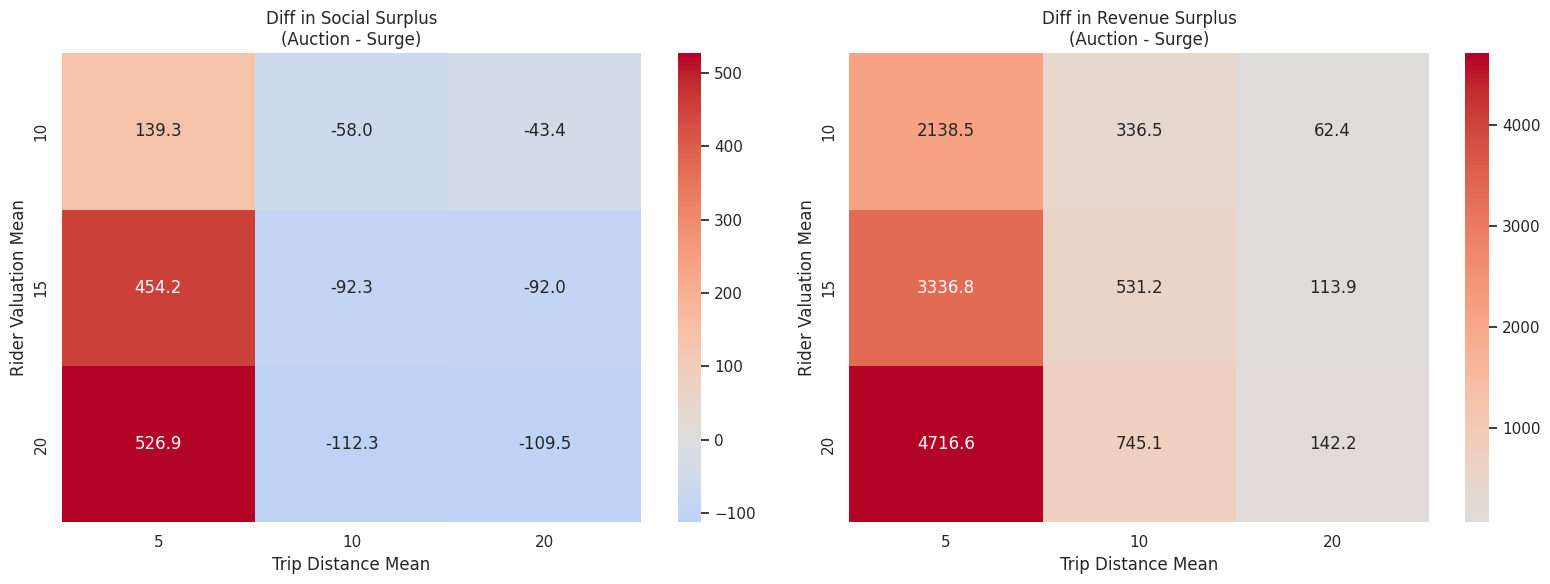

In [ ]:
# Heatmap: Valuation vs Distance means (Average Differences)
pivot_social = df.pivot_table(index='valuation_mean', columns='distance_mean', values='diff_social_surplus', aggfunc='mean')
pivot_revenue = df.pivot_table(index='valuation_mean', columns='distance_mean', values='diff_revenue_surplus', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_social, annot=True, cmap='coolwarm', center=0, ax=axes[0], fmt=".1f")
axes[0].set_title('Diff in Social Surplus\n(Auction - Surge)')
axes[0].set_ylabel('Rider Valuation Mean')
axes[0].set_xlabel('Trip Distance Mean')

sns.heatmap(pivot_revenue, annot=True, cmap='coolwarm', center=0, ax=axes[1], fmt=".1f")
axes[1].set_title('Diff in Revenue Surplus\n(Auction - Surge)')
axes[1].set_ylabel('Rider Valuation Mean')
axes[1].set_xlabel('Trip Distance Mean')

plt.tight_layout()
plt.show()

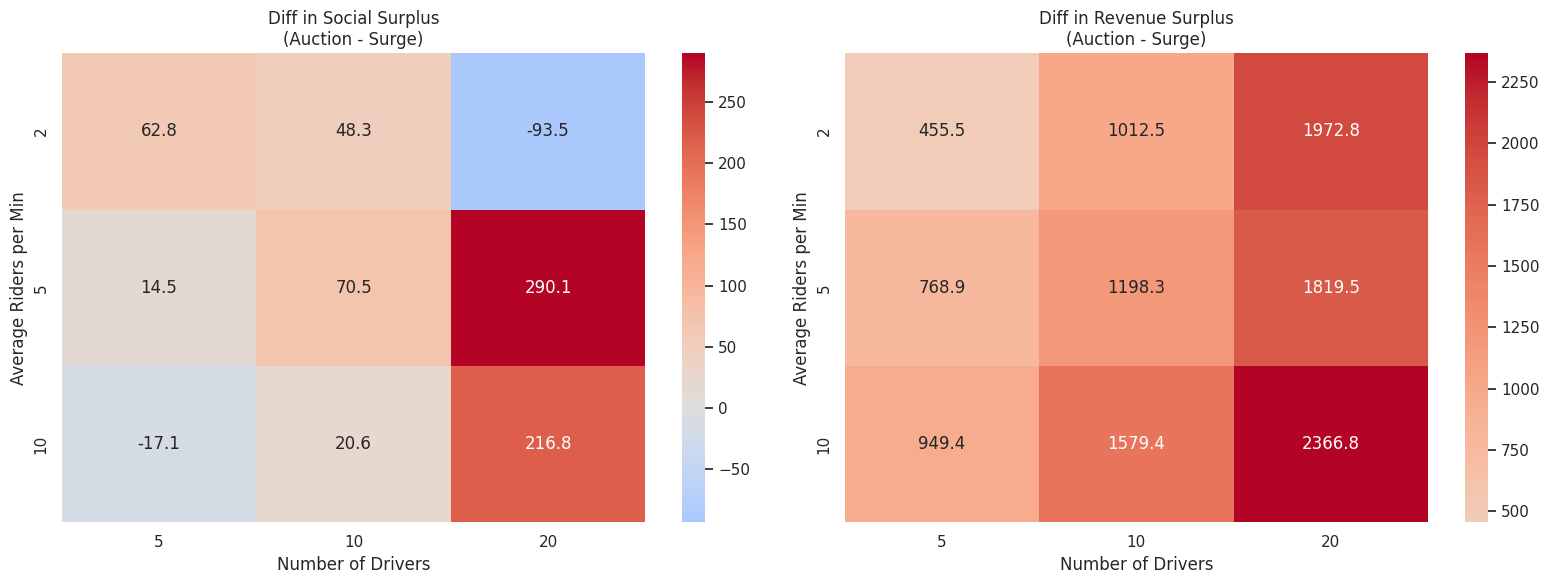

In [ ]:
# Group by driver counts and arrival rates
pivot_social_drivers = df.pivot_table(index='avg_riders_per_min', columns='num_drivers', values='diff_social_surplus', aggfunc='mean')
pivot_revenue_drivers = df.pivot_table(index='avg_riders_per_min', columns='num_drivers', values='diff_revenue_surplus', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_social_drivers, annot=True, cmap='coolwarm', center=0, ax=axes[0], fmt=".1f")
axes[0].set_title('Diff in Social Surplus\n(Auction - Surge)')
axes[0].set_ylabel('Average Riders per Min')
axes[0].set_xlabel('Number of Drivers')

sns.heatmap(pivot_revenue_drivers, annot=True, cmap='coolwarm', center=0, ax=axes[1], fmt=".1f")
axes[1].set_title('Diff in Revenue Surplus\n(Auction - Surge)')
axes[1].set_ylabel('Average Riders per Min')
axes[1].set_xlabel('Number of Drivers')

plt.tight_layout()
plt.show()

## Line Graphs for Trend Analysis
Line graphs to observe the direct impact of the Rider-to-Driver ratio on the surplus differences, as well as the absolute social surplus scaling with the rider valuation.

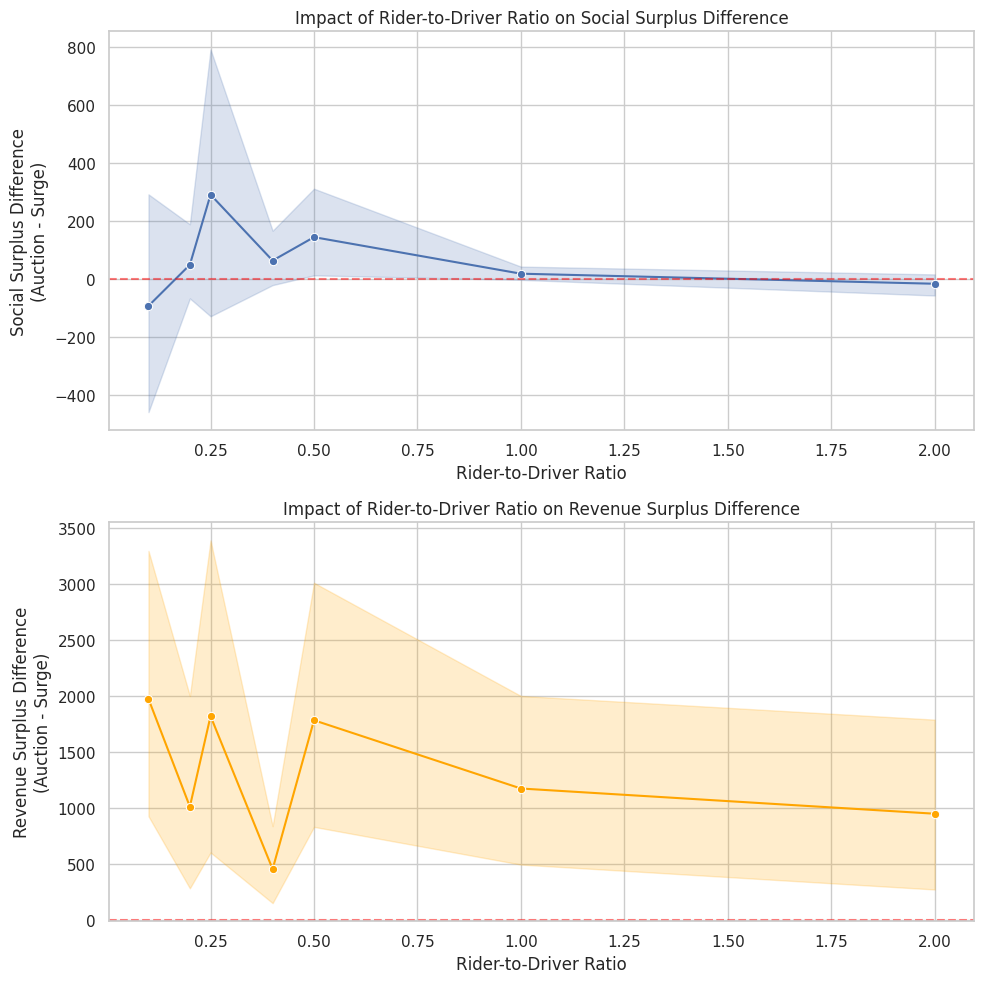

In [ ]:
# Trend 1: How does the Rider-to-Driver ratio affect the surplus differences?
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

sns.lineplot(data=df, x='rider_to_driver_ratio', y='diff_social_surplus', marker='o', ax=axes[0])
axes[0].set_title('Impact of Rider-to-Driver Ratio on Social Surplus Difference')
axes[0].set_xlabel('Rider-to-Driver Ratio')
axes[0].set_ylabel('Social Surplus Difference\n(Auction - Surge)')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5) # Reference line at 0

sns.lineplot(data=df, x='rider_to_driver_ratio', y='diff_revenue_surplus', marker='o', color='orange', ax=axes[1])
axes[1].set_title('Impact of Rider-to-Driver Ratio on Revenue Surplus Difference')
axes[1].set_xlabel('Rider-to-Driver Ratio')
axes[1].set_ylabel('Revenue Surplus Difference\n(Auction - Surge)')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

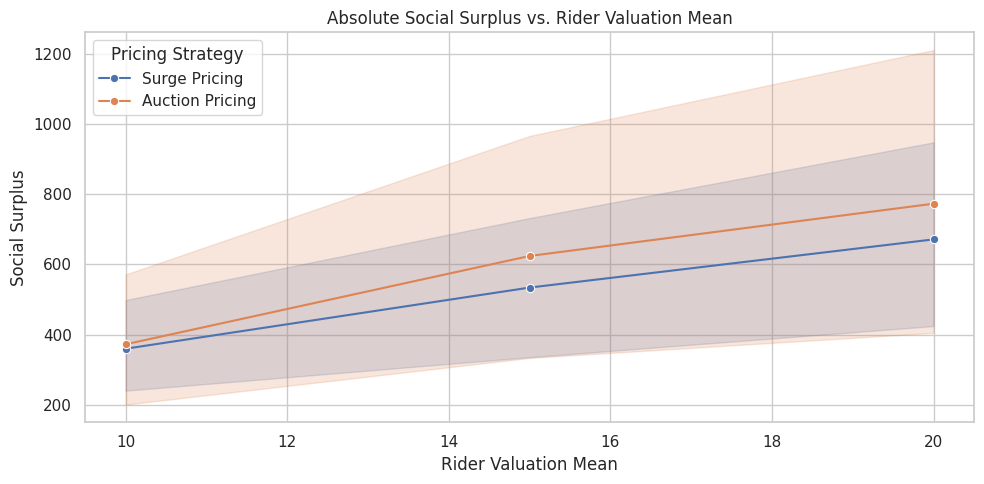

In [ ]:
# Trend 2: Comparing absolute performance across valuation means
plt.figure(figsize=(10, 5))

# Melt the dataframe so we can easily plot both surge and auction lines simultaneously
df_melted_social = df.melt(
    id_vars='valuation_mean', 
    value_vars=['surge_social_surplus', 'auction_social_surplus'], 
    var_name='Pricing Strategy', 
    value_name='Social Surplus'
)

# Clean up label names
df_melted_social['Pricing Strategy'] = df_melted_social['Pricing Strategy'].replace({
    'surge_social_surplus': 'Surge Pricing', 
    'auction_social_surplus': 'Auction Pricing'
})

sns.lineplot(data=df_melted_social, x='valuation_mean', y='Social Surplus', hue='Pricing Strategy', marker='o')
plt.title('Absolute Social Surplus vs. Rider Valuation Mean')
plt.xlabel('Rider Valuation Mean')
plt.ylabel('Social Surplus')

plt.tight_layout()
plt.show()